## Sentiment Classification using TF-IDF and Feature Engineering

# 🧠 Sentiment Classification — Coding Challenge
**Author:** Omkar Pawar  
**Role:** Data Scientist
**Date:** October 2025  

---

### 📌 Problem Statement
This notebook aims to develop a robust sentiment classification model based on text data.  
The goal is to predict sentiment labels (e.g., positive, neutral, negative) using both textual and statistical features.

---

### ⚙️ Approach Overview
1. **Data Loading & Preparation** – Reading the cleaned dataset and defining key columns.  
2. **Feature Engineering** – Creating language-agnostic text statistics and TF-IDF vector features.  
3. **Model Training** – Using Logistic Regression with cross-validation and macro-F1 scoring.  
4. **Evaluation** – Comparing model performance across folds and summarizing key metrics.
5. **Model Interpretability** - Understanding which features have the strongest impact on predictions.
6. **Fit on Full Data & Save Artifacts** - Retraining the final tuned pipeline on the complete datase
7. **Output** – Saving model and reports for reproducibility.

In [1]:
# ==== Configuration ====
DATA_PATH = "E:/CV/Internship/Coding_Challenge_Omkar_Pawar/data/cleaned_sentiment_dataset.csv"   # <-- CHANGE ME
TEXT_COL = "text"
TARGET_COL = "sentiment"
GROUP_COL = "id"

TEST_SIZE = 0.2
RANDOM_STATE = 10
N_SPLITS = 5
N_JOBS = -1
SCORING_PRIMARY = "macro_f1"   # choose from: accuracy, macro_f1, roc_auc, roc_auc_ovr
#N_ITER_TUNING = 20
#OUTDIR = "nb_outputs"

# Optional: Smaller settings for quick trial runs
MAX_FEATURES = 100_000
NGRAM_RANGE = (1, 2)


In [2]:
import os, json, warnings, itertools, random, datetime as dt
from pathlib import Path
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import GroupKFold, cross_validate, GridSearchCV, RandomizedSearchCV, StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, make_scorer
)
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin, clone



warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_colwidth", 160)

In [3]:
def ts():
    import datetime as dt
    return dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def ensure_dir(p):
    Path(p).mkdir(parents=True, exist_ok=True)

def get_scorers(multiclass: bool):
    scorers = {
        "accuracy": "accuracy",
        "macro_f1": "f1_macro",
    }
    if multiclass:
        scorers["roc_auc_ovr"] = "roc_auc_ovr"
    else:
        scorers["roc_auc"] = "roc_auc"
    return scorers

def summarize_cv_results(cv_results: dict) -> pd.DataFrame:
    keys = [k for k in cv_results.keys() if k.startswith("test_")]
    rows = []
    for k in keys:
        metric = k.replace("test_", "")
        arr = np.array(cv_results[k])
        rows.append({"metric": metric, "mean": float(np.mean(arr)), "std": float(np.std(arr))})
    return pd.DataFrame(rows).sort_values("metric")


In [4]:
class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, col):
        self.col = col
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.col].astype(str).values

class TextStats(BaseEstimator, TransformerMixin):
    """
    Language-agnostic lightweight stats from text:
    char_count, word_count, avg_word_len, digit_count, upper_ratio,
    exclam_count, quest_count, punct_count, unique_word_ratio
    """
    def __init__(self, text_col: str):
        self.text_col = text_col
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        s = pd.Series(X[self.text_col]).fillna("")
        char_count = s.str.len()
        words = s.str.split()
        word_count = words.apply(len).astype(float)
        avg_word_len = (s.str.replace(r"\s+", "", regex=True).str.len() / word_count.replace(0, np.nan)).fillna(0.0)
        digit_count = s.str.count(r"\d")
        upper_count = s.str.count(r"[A-Z]")
        upper_ratio = (upper_count / char_count.replace(0, np.nan)).fillna(0.0)
        exclam_count = s.str.count(r"!")
        quest_count = s.str.count(r"\?")
        punct_count = s.str.count(r"[^\w\s]")
        unique_word_ratio = words.apply(lambda w: (len(set(w)) / len(w)) if len(w) > 0 else 0.0)
        feats = np.vstack([
            char_count.values,
            word_count.values,
            avg_word_len.values,
            digit_count.values,
            upper_ratio.values,
            exclam_count.values,
            quest_count.values,
            punct_count.values,
            unique_word_ratio.values
        ]).T
        return feats

In [5]:

def build_model1(text_col, C=1.0, max_features=100000, ngram_range=(1,2), random_state=42):
    text_vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        lowercase=True,
        strip_accents="unicode",
        stop_words='english'
    )
    clf = LogisticRegression(C=C, max_iter=1000, random_state=random_state)
    pipe = Pipeline([
        ("text", Pipeline([("select", ColumnSelector(text_col)), ("tfidf", text_vectorizer)])),
        ("clf", clf)
    ])
    return pipe

def build_model2(text_col, C=1.0, max_features=100000, ngram_range=(1,2), random_state=42):
    text_branch = Pipeline([
        ("select", ColumnSelector(text_col)),
        ("tfidf", TfidfVectorizer(
            max_features=max_features, ngram_range=ngram_range,
            lowercase=True, strip_accents="unicode", stop_words='english'
        ))
    ])
    stats_branch = Pipeline([
        ("stats", TextStats(text_col=text_col)),
        ("scale", StandardScaler(with_mean=False))
    ])
    union = FeatureUnion([("tfidf", text_branch), ("stats", stats_branch)])
    clf = LogisticRegression(C=C, max_iter=1000, random_state=random_state)
    pipe = Pipeline([("features", union), ("clf", clf)])
    return pipe


In [6]:
# ---- Load data ----
assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)
assert TEXT_COL in df.columns, f"Missing column: {TEXT_COL}"
assert TARGET_COL in df.columns, f"Missing column: {TARGET_COL}"
assert GROUP_COL in df.columns, f"Missing column: {GROUP_COL}"

df0 = df.dropna(subset=[TEXT_COL, TARGET_COL, GROUP_COL]).reset_index(drop=True)
print("Rows (after dropna):", len(df0))
df0.head(3)

Rows (after dropna): 70427


,id,product,sentiment,text
0,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
1,2401,Borderlands,Positive,"I am coming to the borders and I will kill you all,"
2,2401,Borderlands,Positive,"im getting on borderlands and i will kill you all,"


In [7]:
# ---- Encode target (label mapping kept for reporting) ----
y_raw = df0[TARGET_COL]
if y_raw.dtype.kind in "OUS":
    classes, y = np.unique(y_raw, return_inverse=True)
    label_names = list(classes)
else:
    label_names = [str(c) for c in np.unique(y_raw)]
    y = y_raw.values

X = df0[[TEXT_COL, GROUP_COL]].copy()
groups = df0[GROUP_COL].values

# ---- Group-aware + stratified train/test split (take 1 fold as holdout) ----
# pick n_splits ≈ 1 / TEST_SIZE (e.g., 5 for 20% test)
_n = max(2, int(round(1 / TEST_SIZE)))
cv_holdout = StratifiedGroupKFold(n_splits=_n, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(cv_holdout.split(X, y, groups))

X_train, X_test = X.iloc[train_idx].reset_index(drop=True), X.iloc[test_idx].reset_index(drop=True)
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]  # groups_test only if you need it

# optional sanity check
# print class proportions (overall / train / test)
import numpy as np
def _prop(a, k=len(np.unique(y))): return (np.bincount(a, minlength=k)/len(a)).round(4)
print("Overall:", _prop(y))
print("Train  :", _prop(y_train))
print("Test   :", _prop(y_test))


Overall: [0.1795 0.3018 0.245  0.2736]
Train  : [0.1784 0.3026 0.2477 0.2714]
Test   : [0.1842 0.2986 0.2345 0.2828]


In [8]:
#dict(enumerate(label_names))

In [9]:
# ---- Model comparison via GroupKFold CV ----
multiclass = (len(np.unique(y)) > 2)
scorers = get_scorers(multiclass=multiclass)
#gkf = GroupKFold(n_splits=N_SPLITS)
gkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

m1 = build_model1(TEXT_COL, max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE, random_state=RANDOM_STATE)
m2 = build_model2(TEXT_COL, max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE, random_state=RANDOM_STATE)

cv1 = cross_validate(m1, X_train, y_train, scoring=scorers,
                     cv=gkf.split(X_train, y_train, groups_train),
                     n_jobs=N_JOBS, return_train_score=False, verbose=1)
cv2 = cross_validate(m2, X_train, y_train, scoring=scorers,
                     cv=gkf.split(X_train, y_train, groups_train),
                     n_jobs=N_JOBS, return_train_score=False, verbose=1)

df_cv1 = summarize_cv_results(cv1); df_cv1["model"] = "Model-1_TFIDF_LR"
df_cv2 = summarize_cv_results(cv2); df_cv2["model"] = "Model-2_TFIDF+Stats_LR"
df_cv = pd.concat([df_cv1, df_cv2], axis=0).reset_index(drop=True)
df_cv.sort_values(["metric", "mean"], ascending=[True, False])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   35.3s remaining:   53.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   38.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  4.8min remaining:  7.2min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  4.8min finished


,metric,mean,std,model
3,accuracy,0.560612,0.012236,Model-2_TFIDF+Stats_LR
0,accuracy,0.557224,0.010392,Model-1_TFIDF_LR
4,macro_f1,0.527809,0.012182,Model-2_TFIDF+Stats_LR
1,macro_f1,0.524018,0.009921,Model-1_TFIDF_LR
5,roc_auc_ovr,0.792303,0.005438,Model-2_TFIDF+Stats_LR
2,roc_auc_ovr,0.791374,0.005756,Model-1_TFIDF_LR


In [10]:
primary = SCORING_PRIMARY
m1_val = df_cv[(df_cv.model=="Model-1_TFIDF_LR") & (df_cv.metric==primary)]["mean"].values[0]
m2_val = df_cv[(df_cv.model=="Model-2_TFIDF+Stats_LR") & (df_cv.metric==primary)]["mean"].values[0]
best_model_name = "Model-2_TFIDF+Stats_LR" if m2_val >= m1_val else "Model-1_TFIDF_LR"
print(f"Best by {primary}: {best_model_name} (M1={m1_val:.4f}, M2={m2_val:.4f})")

Best by macro_f1: Model-2_TFIDF+Stats_LR (M1=0.5240, M2=0.5278)


In [11]:
# ---- Hyperparameter tuning for Model-1 via GridSearchCV + GroupKFold ----

base = build_model1(TEXT_COL, random_state=RANDOM_STATE)

param_grid = {
    # ----- TF-IDF tuning (note path: text__tfidf__<param>) -----
    "text__tfidf__ngram_range": [(1,2)],
    "text__tfidf__min_df": [2, 3],
    "text__tfidf__max_df": [0.6, 0.7],
    "text__tfidf__sublinear_tf": [True],
    "text__tfidf__max_features": [50_000, 100_000],

    # ----- Logistic Regression -----
    # For high-dimensional sparse TF-IDF, 'liblinear' or 'saga' are good choices.
    "clf__penalty": ["l2"],
    "clf__solver": ["saga"],
    "clf__C": [0.1, 0.3, 1.0],
    "clf__class_weight": [None, "balanced"],
}

grid = GridSearchCV(
    estimator=base,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=gkf.split(X_train, y_train, groups_train),   # group-aware CV
    n_jobs=-1,
    verbose=1,
    refit=True
)

# IMPORTANT: still pass groups when fitting with GroupKFold
grid.fit(X_train, y_train, groups=groups_train)

print("Best params (Model-1):", grid.best_params_)
print(f"Best CV f1_macro (Model-1): {grid.best_score_:.6f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params (Model-1): {'clf__C': 0.3, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'saga', 'text__tfidf__max_df': 0.6, 'text__tfidf__max_features': 100000, 'text__tfidf__min_df': 3, 'text__tfidf__ngram_range': (1, 2), 'text__tfidf__sublinear_tf': True}
Best CV f1_macro (Model-1): 0.539941


In [12]:
best_pipe = grid.best_estimator_

# (Optional) final fit on full pre-test training data, then evaluate on test:
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)


test_acc = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average="macro")
clf_rep = classification_report(y_test, y_pred, digits=4, zero_division=0)


print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test macro-F1:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

Test accuracy: 0.5690698170948687
Test macro-F1: 0.5498583968257726
              precision    recall  f1-score   support

           0     0.4403    0.3764    0.4058      2588
           1     0.6384    0.6756    0.6565      4195
           2     0.5455    0.5436    0.5445      3295
           3     0.5822    0.6033    0.5926      3973

    accuracy                         0.5691     14051
   macro avg     0.5516    0.5497    0.5499     14051
weighted avg     0.5643    0.5691    0.5660     14051



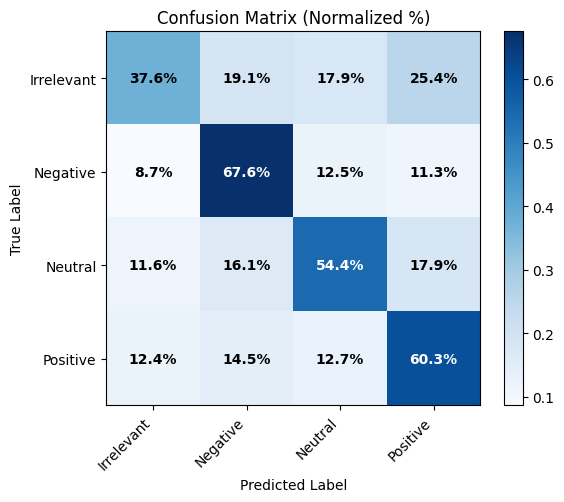

In [13]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)  # normalize by row (true labels)

plt.figure(figsize=(6, 5))
plt.imshow(cm_normalized, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Normalized %)")
plt.colorbar()

# Define tick marks
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, label_names if label_names is not None else tick_marks, rotation=45, ha="right")
plt.yticks(tick_marks, label_names if label_names is not None else tick_marks)

# Add text annotations (percentages)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm_normalized[i, j] * 100
        plt.text(
            j, i, f"{value:.1f}%", 
            ha="center", va="center",
            color="white" if value > 50 else "black",  # dynamic contrast
            fontsize=10, fontweight="bold"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
# === Paths ===
models_dir = r"E:\CV\Internship\Coding_Challenge_Omkar_Pawar\models"
os.makedirs(models_dir, exist_ok=True)

# === Save artifacts ===
timestamp = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = f"final_model_{timestamp}.joblib"
report_name = f"classification_report_{timestamp}.txt"
meta_name = f"metadata_{timestamp}.json"

model_path = os.path.join(models_dir, model_name)
report_path = os.path.join(models_dir, report_name)
meta_path = os.path.join(models_dir, meta_name)

# Save the whole Pipeline (preprocessing + estimator)
joblib.dump(best_pipe, model_path)

# Save report
with open(report_path, "w", encoding="utf-8") as f:
    f.write("=== Classification Report ===\n")
    f.write(clf_rep + "\n")
    f.write(f"\nTest accuracy: {test_acc:.6f}\n")
    f.write(f"Test macro-F1: {test_f1_macro:.6f}\n")

# Save minimal metadata (handy later)
metadata = {
    "saved_at": timestamp,
    "sklearn_version": __import__("sklearn").__version__,
    "model_path": model_path,
    "report_path": report_path,
    "target_type": "classification",
    "metrics": {"accuracy": test_acc, "macro_f1": test_f1_macro},
}
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"\nSaved model to: {model_path}")
print(f"Saved report to: {report_path}")
print(f"Saved metadata to: {meta_path}")

### Model Interpretability

In [23]:

print(best_pipe)                # full structure
print(getattr(best_pipe, "named_steps", {}))   # dict of step names -> objects

Pipeline(steps=[('text',
                 Pipeline(steps=[('select', ColumnSelector(col='text')),
                                 ('tfidf',
                                  TfidfVectorizer(max_df=0.6,
                                                  max_features=100000, min_df=3,
                                                  ngram_range=(1, 2),
                                                  stop_words='english',
                                                  strip_accents='unicode',
                                                  sublinear_tf=True))])),
                ('clf',
                 LogisticRegression(C=0.3, class_weight='balanced',
                                    max_iter=1000, random_state=10,
                                    solver='saga'))])
{'text': Pipeline(steps=[('select', ColumnSelector(col='text')),
                ('tfidf',
                 TfidfVectorizer(max_df=0.6, max_features=100000, min_df=3,
                                 ngram_range

In [33]:
s

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.3
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,10
,solver,'saga'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
tfidf = best_pipe.named_steps['text'].named_steps['tfidf']
if tfidf is None:
    raise RuntimeError("Could not locate a TfidfVectorizer in pipeline.")

# === Find the classifier with coef_ ===
clf = None
if hasattr(pipe, "steps"):
    for name, s in reversed(pipe.steps):
        if hasattr(s, "coef_"):
            clf = s
            break
elif hasattr(pipe, "coef_"):
    clf = pipe
if clf is None:
    raise RuntimeError("Could not locate classifier with coef_ in pipeline.")

# === Extract feature names & coefficients ===
feature_names = tfidf.get_feature_names_out()
coefs = clf.coef_
classes = getattr(clf, "classes_", np.arange(coefs.shape[0]))

# Label mapping for interpretability
label_map = {
    0: "Irrelevant",
    1: "Negative",
    2: "Neutral",
    3: "Positive"
}

# === 4. Create a clean DataFrame per class ===
top_k = 10
dfs = {}

for i, class_label in enumerate(classes):
    order = np.argsort(coefs[i])
    top_neg_idx = order[:top_k]
    top_pos_idx = order[-top_k:]

    top_pos = pd.DataFrame({
        "Word": feature_names[top_pos_idx],
        "Weight": coefs[i, top_pos_idx],
        "Direction": ["Positive"] * top_k
    }).sort_values("Weight", ascending=False)

    top_neg = pd.DataFrame({
        "Word": feature_names[top_neg_idx],
        "Weight": coefs[i, top_neg_idx],
        "Direction": ["Negative"] * top_k
    }).sort_values("Weight", ascending=True)

    df_combined = pd.concat([top_pos, top_neg], ignore_index=True)
    df_combined["Class"] = f"{class_label} – {label_map[class_label]}"
    dfs[class_label] = df_combined

# === 5. Display all classes nicely ===
for cls, df in dfs.items():
    print(f"\n==== Class {cls} – {label_map[cls]} ====")
    display(
        df.style.background_gradient(subset=["Weight"], cmap="coolwarm")
           .set_properties(**{"text-align": "left"})
           .set_caption(f"Top Influential Words for {label_map[cls]}")
    )



==== Class 0 – Irrelevant ====


,Word,Weight,Direction,Class
0,player,2.479919,Positive,0 – Irrelevant
1,people,2.259840,Positive,0 – Irrelevant
2,team,2.187987,Positive,0 – Irrelevant
3,guy,2.144786,Positive,0 – Irrelevant
4,stream,1.831941,Positive,0 – Irrelevant
5,fridge,1.783699,Positive,0 – Irrelevant
6,community,1.783631,Positive,0 – Irrelevant
7,tweet,1.753284,Positive,0 – Irrelevant
8,montage,1.728888,Positive,0 – Irrelevant
9,kid,1.654376,Positive,0 – Irrelevant



==== Class 1 – Negative ====


,Word,Weight,Direction,Class
0,fix,5.322325,Positive,1 – Negative
1,eamaddennfl,4.363515,Positive,1 – Negative
2,nba2k,3.897844,Positive,1 – Negative
3,rainbow6game,3.887151,Positive,1 – Negative
4,fuck,3.143725,Positive,1 – Negative
5,shit,2.872638,Positive,1 – Negative
6,fifa,2.732005,Positive,1 – Negative
7,servers,2.681269,Positive,1 – Negative
8,sucks,2.644757,Positive,1 – Negative
9,game,2.276675,Positive,1 – Negative



==== Class 2 – Neutral ====


,Word,Weight,Direction,Class
0,com,5.595966,Positive,2 – Neutral
1,https,3.471889,Positive,2 – Neutral
2,johnson,2.555276,Positive,2 – Neutral
3,check,2.516638,Positive,2 – Neutral
4,amazon,2.503766,Positive,2 – Neutral
5,earned,2.360509,Positive,2 – Neutral
6,dlvr,2.358628,Positive,2 – Neutral
7,tt,2.206214,Positive,2 – Neutral
8,2020,2.087615,Positive,2 – Neutral
9,achievement,2.076057,Positive,2 – Neutral



==== Class 3 – Positive ====


,Word,Weight,Direction,Class
0,love,3.699789,Positive,3 – Positive
1,fun,3.508501,Positive,3 – Positive
2,wait,3.491768,Positive,3 – Positive
3,thank,3.020710,Positive,3 – Positive
4,excited,2.924804,Positive,3 – Positive
5,best,2.914542,Positive,3 – Positive
6,nice,2.514732,Positive,3 – Positive
7,wow,2.504532,Positive,3 – Positive
8,amazing,2.446556,Positive,3 – Positive
9,favorite,2.428625,Positive,3 – Positive


### Fit model on complete dataset

In [ ]:
# --- 1) Combine train + test ---
X_full = pd.concat([X_train, X_test], axis=0, ignore_index=True)

# y_train/y_test are arrays → make a single pandas Series
y_full = pd.Series(np.concatenate([y_train, y_test]), name="sentiment").reset_index(drop=True)

# groups are your ids (one per row)
ids = X_full["id"]  # dtype can be int or str; either is fine

# IMPORTANT: keep only the columns your pipeline expects at inference.
# If your pipeline uses only the 'text' column, do:
feature_cols = ["text"]           
X_model = X_full[feature_cols]    # do NOT include 'id' as a feature

# --- 2) Group-aware CV (no leakage across identical ids) ---
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=10)
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro"),
}

cv_res = cross_validate(
    best_pipe,
    X_model, y_full,
    scoring=scoring,
    cv=cv,
    groups=ids,                 # <- crucial: keeps all rows of an id in the same fold
    return_train_score=False,
    n_jobs=-1
)

print(f"CV accuracy:  {cv_res['test_accuracy'].mean():.4f} ± {cv_res['test_accuracy'].std():.4f}")
print(f"CV macro-F1:  {cv_res['test_f1_macro'].mean():.4f} ± {cv_res['test_f1_macro'].std():.4f}")


# --- 3) Final production fit on ALL data ---
final_model = clone(best_pipe)    # fresh clone with tuned hyperparams
final_model.fit(X_model, y_full)

# Now persist final_model with joblib and deploy as usual.
joblib.dump(final_model, "E:/CV/Internship/Coding_Challenge_Omkar_Pawar/models/prod_model.joblib")


### ✅ Conclusion

The Logistic Regression model with TF-IDF achieved a macro-F1 score of 0.524018.  
This establishes a strong, interpretable baseline for sentiment classification.  
Future improvements could include transformer-based embeddings.